# Network and Communities — Reply Graph

**Project:** *The Devil Wears Prada 2* — Social Media Analysis
**Platform:** Bluesky

This notebook constructs the reply network from the data collected in `01_full_collection_bluesky.ipynb`, computes structural properties and centrality measures, and applies four community detection algorithms to identify the dominant conversational sub-structures.

The graph is built on author handles: an edge connects the author of a reply to the author of the post being replied to. The construction proceeds in three phases.
1. The **first phase** assembles, cleans and characterises the full reply graph across the entire dataset.
2. The **second phase** focuses on the giant connected component and compares the four community detection algorithms on it.
3. The **third phase** writes the derived datasets to disk for use in the content-analysis notebook.

All outputs are saved under `data/processed/`, leaving the raw collection in `data/raw/` untouched.


## 1. Setup

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
import community as community_louvain
from networkx.algorithms.community import (
    greedy_modularity_communities,
    asyn_fluidc,
    girvan_newman,
)
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RAW_DIR  = Path("../data/raw")
PROC_DIR = Path("../data/processed")
FIG_DIR = Path("../figures")
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


Posts and replies are loaded from the JSON Lines files produced by the full-collection notebook.

In [2]:
df_posts = pd.read_json(RAW_DIR / "bluesky_posts_full.jsonl", lines=True)
df_replies = pd.read_json(RAW_DIR / "bluesky_replies_full.jsonl", lines=True)

df_posts["created_at"]   = pd.to_datetime(df_posts["created_at"], utc=True, errors="coerce")
df_replies["created_at"] = pd.to_datetime(df_replies["created_at"], utc=True, errors="coerce")

print(f"Posts loaded:   {len(df_posts):,}")
print(f"Replies loaded: {len(df_replies):,}")


Posts loaded:   3,869
Replies loaded: 2,337


## 2. Structural pre-analysis

Three pieces of information are needed before assembling the edge list.
1. The first is the share of posts that are themselves replies returned by search (and therefore carry a `reply_parent_uri`): these can contribute edges if the parent's author is also in the dataset.
2. The second is the number of self-loops in the raw reply data — that is, replies whose author equals the parent's author, typically corresponding to long thread-style posts split across consecutive bubbles.
3. The third is the share of replies whose parent author can be resolved through the union of posts and replies.


In [3]:
# Replies among the search-collected posts
search_replies = df_posts[df_posts["is_reply"] == True].copy()
print(f"Search-collected replies (is_reply=True): {len(search_replies):,}")

# Build a global uri → author handle map (posts + replies)
uri_to_author = dict(zip(df_posts["uri"], df_posts["author_handle"]))
uri_to_author.update(dict(zip(df_replies["uri"], df_replies["author_handle"])))

# Resolve parent_author_handle for search-replies (it is not present in the original collection)
search_replies["parent_author_handle"] = search_replies["reply_parent_uri"].map(uri_to_author)
resolved_search_replies = search_replies["parent_author_handle"].notna().sum()
print(f"  └─ with parent author resolvable: {resolved_search_replies}")
print(f"  └─ parent outside the dataset:    {len(search_replies) - resolved_search_replies}")

# Self-loops in thread-expansion replies
self_loops = (df_replies["author_handle"] == df_replies["parent_author_handle"]).sum()
print(f"\nThread-expansion replies:          {len(df_replies):,}")
print(f"  └─ self-loops (author = parent):  {self_loops}")
print(f"  └─ non-self-loops:                {len(df_replies) - self_loops}")


Search-collected replies (is_reply=True): 381
  └─ with parent author resolvable: 54
  └─ parent outside the dataset:    327

Thread-expansion replies:          2,337
  └─ self-loops (author = parent):  464
  └─ non-self-loops:                1873


## 3. Self-loop characterisation

Bluesky encourages users to break long thoughts into chained posts, each one replying to the previous one by the same author. These chains produce self-loops in the reply graph because both endpoints are the same handle. Looking at which authors generate the most self-loops separates two cases: legitimate analytical threads, and template-based promotional accounts that repost the same content with minor variations.


In [4]:
self_loop_rows = df_replies[df_replies["author_handle"] == df_replies["parent_author_handle"]]
top_self_repliers = self_loop_rows["author_handle"].value_counts().head(10)

print("Top 10 authors by number of self-replies:")
print(top_self_repliers)


Top 10 authors by number of self-replies:
author_handle
ourmovieguide.bsky.social        13
thelazycapricorn.blacksky.app     8
fleerultra.bsky.social            8
hollywoodmemories.bsky.social     8
multinerdz.bsky.social            7
lennessy.bsky.social              7
walinchus.bsky.social             7
originalsp.in                     7
alissawilkinson.bsky.social       7
nuriamachado.bsky.social          7
Name: count, dtype: int64


Self-loops are removed from the reply graph because the unit of analysis is the **interaction between users**: chained self-replies represent a single author's monologue rather than a conversation between two participants. The flag `is_likely_promo` is added to the node attributes below to capture authors with an unusually high number of self-replies, so that their structural role can be re-examined during interpretation without excluding them from the analysis.


## 4. Edge list construction

The reply network is built from two complementary sources of interaction data.

1. First, we use the replies collected through thread expansion. These records already include both the reply author and the parent author, allowing us to directly create reply-based interactions.

2. Second, we include search-collected replies for which the parent author could be resolved from the available post/reply metadata. This allows us to recover additional interactions that appeared in the search results but were not necessarily collected during thread expansion.

3. For both sources, an edge is defined as a directed interaction from the user who wrote the reply to the user who authored the parent post or parent reply. Self-loops, where a user replies to their own content, are removed for the network analysis because the graph is intended to capture interactions between different users.

4. Finally, repeated interactions between the same pair of users are aggregated into weighted edges. The edge weight represents the number of replies sent from the source user to the target user across the full dataset.


In [5]:
# Combine reply sources
edges_thread = df_replies[["author_handle", "parent_author_handle"]].dropna()
edges_search = (
    search_replies[search_replies["parent_author_handle"].notna()]
    [["author_handle", "parent_author_handle"]]
)
edges_all = pd.concat([edges_thread, edges_search], ignore_index=True)
print(f"Raw edges (thread + search):  {len(edges_all):,}")

# Drop self-loops
edges_no_self = edges_all[edges_all["author_handle"] != edges_all["parent_author_handle"]].copy()
print(f"After dropping self-loops:    {len(edges_no_self):,}")

# Aggregate into weighted directed pairs
edges_weighted = (
    edges_no_self
    .groupby(["author_handle", "parent_author_handle"])
    .size()
    .reset_index(name="weight")
    .rename(columns={"author_handle": "source", "parent_author_handle": "target"})
)
print(f"Unique weighted edges:        {len(edges_weighted):,}")
print(f"Max edge weight:              {edges_weighted['weight'].max()}")
print(f"Edges with weight > 1:        {(edges_weighted['weight'] > 1).sum()}")

edges_weighted.head()


Raw edges (thread + search):  2,391
After dropping self-loops:    1,893
Unique weighted edges:        1,605
Max edge weight:              5
Edges with weight > 1:        228


,source,target,weight
0,08mms.bsky.social,broccolirob.gobirds.online,1
1,116flor.bsky.social,bobby1998.bsky.social,1
2,1800000burn.hyper.wang,ninejackals.bsky.social,1
3,27cansoftuna.bsky.social,chronolynx.bsky.social,1
4,2intheshinx.bsky.social,mattyb123.bsky.social,1


## 5. Graph construction

Two graphs are built from the same edge list.
- The **directed graph** preserves the asymmetry between replying and being replied to and is used for in-degree and out-degree centrality.
- The **undirected graph** collapses that asymmetry by summing the weights in both directions and is used for community detection and for closeness, betweenness and eigenvector centrality.


In [6]:
# Directed graph
G_dir = nx.from_pandas_edgelist(
    edges_weighted, source="source", target="target",
    edge_attr="weight", create_using=nx.DiGraph,
)

# Undirected graph: collapse pairs and sum weights
edges_und = (
    edges_weighted
    .assign(pair=edges_weighted.apply(
        lambda r: tuple(sorted((r["source"], r["target"]))), axis=1
    ))
    .groupby("pair", as_index=False)["weight"].sum()
)
edges_und[["u", "v"]] = pd.DataFrame(edges_und["pair"].tolist(), index=edges_und.index)
G_und = nx.from_pandas_edgelist(
    edges_und, source="u", target="v",
    edge_attr="weight", create_using=nx.Graph,
)

print(f"Directed graph:   {G_dir.number_of_nodes():,} nodes, {G_dir.number_of_edges():,} edges")
print(f"Undirected graph: {G_und.number_of_nodes():,} nodes, {G_und.number_of_edges():,} edges")


Directed graph:   1,554 nodes, 1,605 edges
Undirected graph: 1,554 nodes, 1,218 edges


## 6. Promotional-account flag

A node is flagged as likely promotional when its author shows a heavy self-reply pattern (five or more self-replies in the thread-expansion data). The threshold is conservative: it identifies accounts whose presence in the graph is dominated by template-based, often promotional, content. The flag is stored as a node attribute and propagated to the saved CSV; it is not used to remove nodes from the graph.


In [7]:
PROMO_THRESHOLD = 5
promo_authors = set(top_self_repliers[top_self_repliers >= PROMO_THRESHOLD].index)

for node in G_dir.nodes():
    G_dir.nodes[node]["is_likely_promo"] = node in promo_authors
for node in G_und.nodes():
    G_und.nodes[node]["is_likely_promo"] = node in promo_authors

print(f"Authors flagged as likely promotional: {len(promo_authors)}")
print(f"Threshold:                             {PROMO_THRESHOLD}+ self-replies")
print(f"Examples: {sorted(promo_authors)[:5]}")


Authors flagged as likely promotional: 10
Threshold:                             5+ self-replies
Examples: ['alissawilkinson.bsky.social', 'fleerultra.bsky.social', 'hollywoodmemories.bsky.social', 'lennessy.bsky.social', 'multinerdz.bsky.social']


## 7. Global statistics — full graph

Standard structural indicators for the undirected graph: node and edge counts, density, distribution of node degree (a node's degree is the number of distinct authors it interacted with through replies), and average clustering coefficient.


In [8]:
n_nodes = G_und.number_of_nodes()
n_edges = G_und.number_of_edges()
density = nx.density(G_und)
avg_clustering = nx.average_clustering(G_und)

deg_seq = [d for _, d in G_und.degree()]
deg_stats = pd.Series(deg_seq).describe(percentiles=[.5, .75, .9, .95, .99]).round(2)

print(f"Nodes:                  {n_nodes:,}")
print(f"Edges:                  {n_edges:,}")
print(f"Density:                {density:.4f}")
print(f"Average clustering:     {avg_clustering:.4f}")
print(f"\nDegree distribution:")
print(deg_stats)


Nodes:                  1,554
Edges:                  1,218
Density:                0.0010
Average clustering:     0.0245

Degree distribution:
count    1554.00
mean        1.57
std         2.58
min         1.00
50%         1.00
75%         1.00
90%         2.00
95%         4.00
99%        11.00
max        67.00
dtype: float64


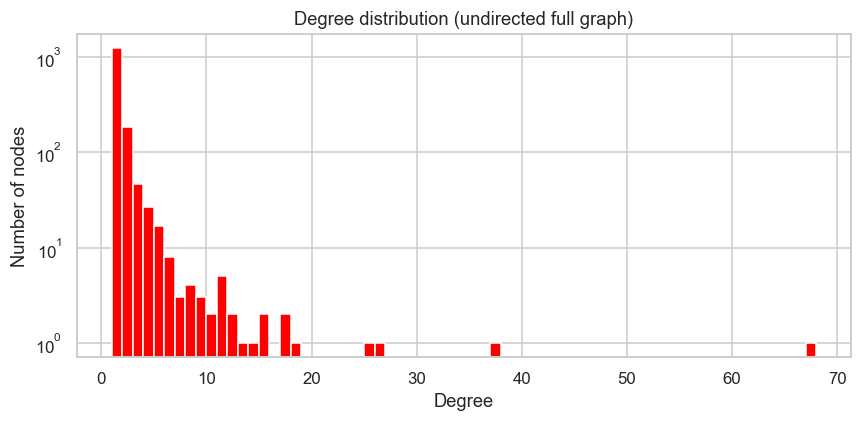

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(deg_seq, bins=range(1, max(deg_seq) + 2), color="#ff0000", edgecolor="white")
ax.set_xlabel("Degree")
ax.set_ylabel("Number of nodes")
ax.set_yscale("log")
ax.set_title("Degree distribution (undirected full graph)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_degree_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



## 8. Connected components

The reply graph is highly fragmented: the conversation does not form a single large network but many small ones around specific viral posts. The distribution of component sizes quantifies this fragmentation.


In [10]:
components = sorted(nx.connected_components(G_und), key=len, reverse=True)

comp_sizes = pd.Series([len(c) for c in components])
print(f"Number of connected components: {len(components):,}")
print(f"Size of giant component:        {comp_sizes.iloc[0]} ({comp_sizes.iloc[0]/n_nodes:.1%} of nodes)")
print(f"\nComponent size distribution:")
print(pd.cut(comp_sizes, bins=[1, 2, 3, 5, 10, 50, 1000])
        .value_counts()
        .sort_index()
        .rename("components")
        .to_frame())


Number of connected components: 371
Size of giant component:        88 (5.7% of nodes)

Component size distribution:
            components
(1, 2]             216
(2, 3]              72
(3, 5]              34
(5, 10]             28
(10, 50]            19
(50, 1000]           2


In [11]:
top_components = pd.DataFrame({
    "rank": range(1, 11),
    "nodes": [len(c) for c in components[:10]],
})
top_components["edges"] = [G_und.subgraph(c).number_of_edges() for c in components[:10]]
top_components["density"] = [round(nx.density(G_und.subgraph(c)), 4) for c in components[:10]]
top_components


,rank,nodes,edges,density
0,1,88,98,0.0256
1,2,66,68,0.0317
2,3,42,43,0.0499
3,4,40,42,0.0538
4,5,39,38,0.0513
5,6,34,37,0.0660
6,7,30,29,0.0667
7,8,22,21,0.0909
8,9,21,21,0.1000
9,10,21,21,0.1000


### Figure: top 20 components by size

A bar chart of the twenty largest connected components makes the long-tailed fragmentation immediately visible. The giant component stands out, followed by a small set of medium components and a long tail of micro-conversations (most of which are two-node pairs).


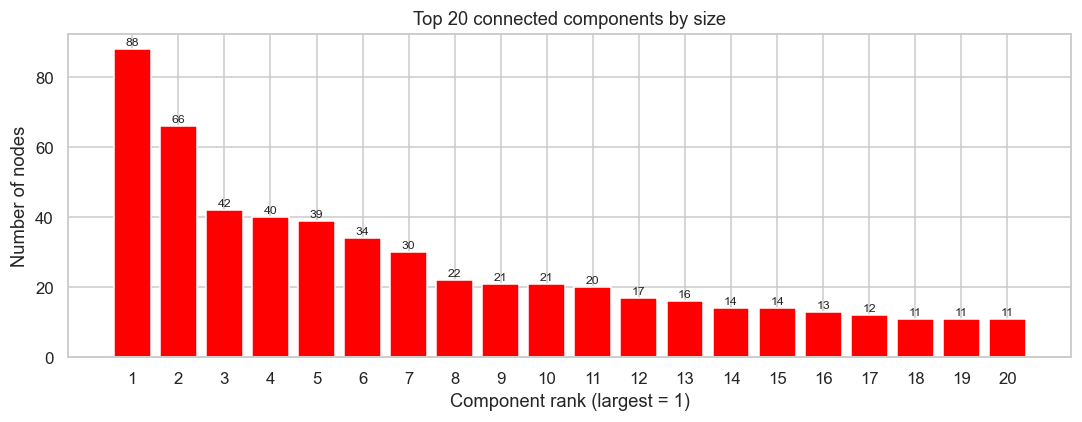

In [12]:
top_n = 20
sizes_top = [len(c) for c in components[:top_n]]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, top_n + 1), sizes_top, color="#ff0000", edgecolor="white")
ax.set_xlabel("Component rank (largest = 1)")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Top {top_n} connected components by size")
ax.set_xticks(range(1, top_n + 1))
for i, v in enumerate(sizes_top):
    ax.text(i + 1, v + 1, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_top20_components_by_size.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Centrality — full graph

Four centrality measures are computed:
1. in-degree on the directed graph,
2. out-degree on the directed graph,
3. betweenness on the undirected graph,
4. eigenvector centrality on the undirected graph

In-degree counts how many distinct authors replied to a node, out-degree how many distinct authors a node replied to. Betweenness identifies nodes that lie on many shortest paths between others. Eigenvector captures the recursive notion that a node is important when connected to other important nodes.


In [13]:
in_deg  = pd.Series(dict(G_dir.in_degree(weight="weight")),  name="in_degree")
out_deg = pd.Series(dict(G_dir.out_degree(weight="weight")), name="out_degree")
btw     = pd.Series(nx.betweenness_centrality(G_und, weight="weight"), name="betweenness")

try:
    eig = pd.Series(
        nx.eigenvector_centrality_numpy(G_und, weight="weight"),
        name="eigenvector",
    )
except Exception:
    # Fallback for disconnected graphs on older numpy versions
    eig = pd.Series(
        nx.eigenvector_centrality(G_und, weight="weight", max_iter=1000),
        name="eigenvector",
    )

centrality_full = pd.concat([in_deg, out_deg, btw, eig], axis=1).fillna(0)
centrality_full["is_likely_promo"] = centrality_full.index.isin(promo_authors)
centrality_full = centrality_full.sort_values("in_degree", ascending=False)

print(f"Top 15 authors by in-degree (most-replied):")
centrality_full.head(15).round(4)


Top 15 authors by in-degree (most-replied):


,in_degree,out_degree,betweenness,eigenvector,is_likely_promo
squeakyllama.bsky.social,69,3,0.0030,0.0000,False
cassiarowland.bsky.social,37,0,0.0006,0.0000,False
fleerultra.bsky.social,27,5,0.0003,0.0000,True
popcrave.com,27,0,0.0015,0.0000,False
film-authority.bsky.social,24,24,0.0000,0.7073,False
theferocity.bsky.social,18,6,0.0002,0.0000,False
gravitysra1nbow.bsky.social,18,3,0.0004,0.0000,False
mollyknight.bsky.social,18,1,0.0002,0.0000,False
ptklein.com,18,8,0.0005,0.0000,False
nicetopatrick.bsky.social,16,2,0.0004,0.0000,False


In [14]:
print("Top 15 authors by betweenness (bridges across conversations):")
centrality_full.sort_values("betweenness", ascending=False).head(15).round(4)


Top 15 authors by betweenness (bridges across conversations):


,in_degree,out_degree,betweenness,eigenvector,is_likely_promo
squeakyllama.bsky.social,69,3,0.0030,0.0,False
popcrave.com,27,0,0.0015,0.0,False
alexdualgrey.bsky.social,2,4,0.0008,0.0,False
cassiarowland.bsky.social,37,0,0.0006,0.0,False
pinkponysub.bsky.social,15,5,0.0005,0.0,False
kikkiplanet.bsky.social,11,2,0.0005,0.0,False
allthingsdre.bsky.social,0,2,0.0005,0.0,False
ptklein.com,18,8,0.0005,0.0,False
nicetopatrick.bsky.social,16,2,0.0004,0.0,False
mattielubchansky.com,13,3,0.0004,0.0,False


### Figure: top authors by centrality

Stacking the three primary centrality measures side by side reveals an important distinction.
- Some accounts are central because they *receive* many replies (high in-degree, e.g. the author of a viral post);

- others because they *send* many replies (high out-degree, typically active commenters);

- a third group because they sit on paths between others (high betweenness, structural bridges). The same author rarely tops all three rankings, and the bar chart makes the divergence explicit.


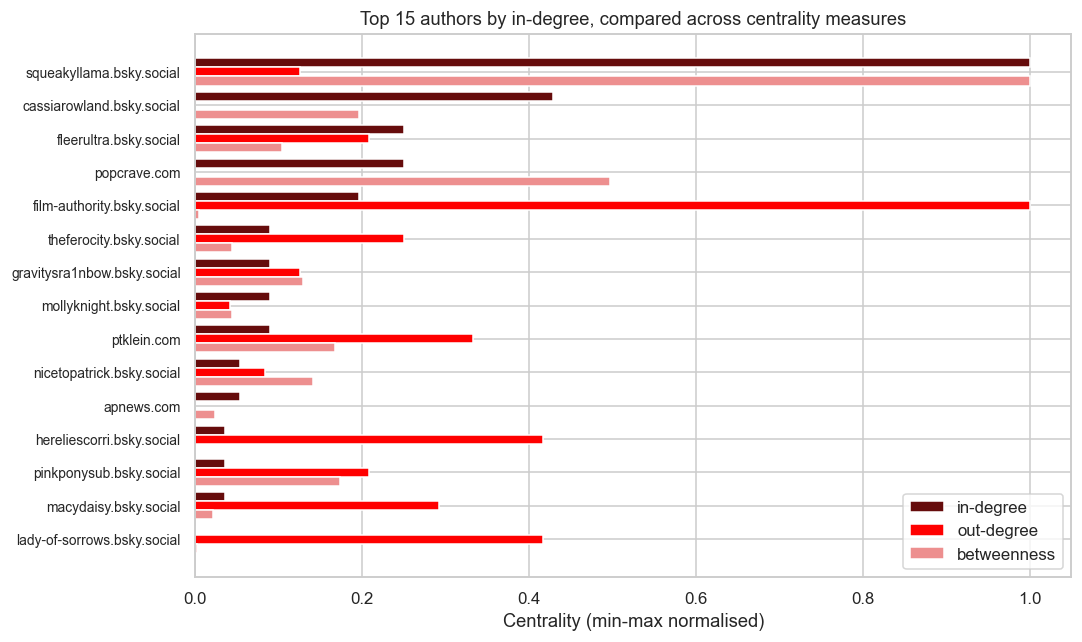

In [15]:
top_k = 15

# Min-max normalise each centrality measure to [0, 1] so the bars are comparable.
def _minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0.0

top_by_indeg = centrality_full.sort_values("in_degree", ascending=False).head(top_k).index
chart_df = centrality_full.loc[top_by_indeg, ["in_degree", "out_degree", "betweenness"]].copy()
chart_df_norm = chart_df.apply(_minmax)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(chart_df_norm))
height = 0.27
ax.barh(y - height, chart_df_norm["in_degree"],   height, label="in-degree",   color="#660c0c")
ax.barh(y,          chart_df_norm["out_degree"],  height, label="out-degree",  color="#ff0000")
ax.barh(y + height, chart_df_norm["betweenness"], height, label="betweenness", color="#ed8f8f")
ax.set_yticks(y)
ax.set_yticklabels(chart_df_norm.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Centrality (min-max normalised)")
ax.set_title(f"Top {top_k} authors by in-degree, compared across centrality measures")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_centrality_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Giant component

The community detection algorithms compared all require, or are best applied to, a connected graph. The giant component is extracted here and used as the common substrate for the four algorithms, so that their outputs are directly comparable.


In [16]:
giant_nodes = components[0]
G_giant = G_und.subgraph(giant_nodes).copy()

print(f"Giant component:")
print(f"  Nodes:    {G_giant.number_of_nodes()}")
print(f"  Edges:    {G_giant.number_of_edges()}")
print(f"  Density:  {nx.density(G_giant):.4f}")
print(f"  Diameter: {nx.diameter(G_giant)}")
print(f"  Avg path: {nx.average_shortest_path_length(G_giant):.2f}")


Giant component:
  Nodes:    88
  Edges:    98
  Density:  0.0256
  Diameter: 6
  Avg path: 2.44


In [17]:
# Centrality measures restricted to the giant component
in_deg_g   = pd.Series(dict(G_dir.subgraph(giant_nodes).in_degree(weight="weight")),  name="in_degree")
out_deg_g  = pd.Series(dict(G_dir.subgraph(giant_nodes).out_degree(weight="weight")), name="out_degree")
btw_g      = pd.Series(nx.betweenness_centrality(G_giant, weight="weight"), name="betweenness")
clo_g      = pd.Series(nx.closeness_centrality(G_giant, distance="weight"), name="closeness")
eig_g      = pd.Series(nx.eigenvector_centrality_numpy(G_giant, weight="weight"), name="eigenvector")

centrality_giant = pd.concat([in_deg_g, out_deg_g, btw_g, clo_g, eig_g], axis=1).fillna(0)
centrality_giant["is_likely_promo"] = centrality_giant.index.isin(promo_authors)
centrality_giant = centrality_giant.sort_values("in_degree", ascending=False)

print("Top 15 authors in the giant component by in-degree:")
centrality_giant.head(15).round(4)


Top 15 authors in the giant component by in-degree:


,in_degree,out_degree,betweenness,closeness,eigenvector,is_likely_promo
squeakyllama.bsky.social,69,3,0.9666,0.7250,0.6835,False
prdnme.bsky.social,7,1,0.0785,0.3398,0.2063,False
silentbrouhaha.bsky.social,4,1,0.1267,0.4628,0.1024,False
ebcollis.bsky.social,4,2,0.0901,0.4394,0.0927,False
polly-o.bsky.social,4,4,0.0521,0.3398,0.2706,False
sdzdc.bsky.social,2,5,0.0118,0.4307,0.1247,False
philcox99.bsky.social,2,2,0.0000,0.4223,0.1098,False
rekati.bsky.social,1,1,0.0230,0.4265,0.0717,False
nikkipearl.bsky.social,1,1,0.0230,0.4265,0.0717,False
livesantacruz.bsky.social,1,2,0.0230,0.4265,0.0742,False


### Figure: full reply graph overview

A single layout of the entire reply network shows the dominant pattern at a glance: a small dense core (the giant component) surrounded by a wide cloud of small disconnected components. Nodes belonging to the giant are coloured for visual contrast.


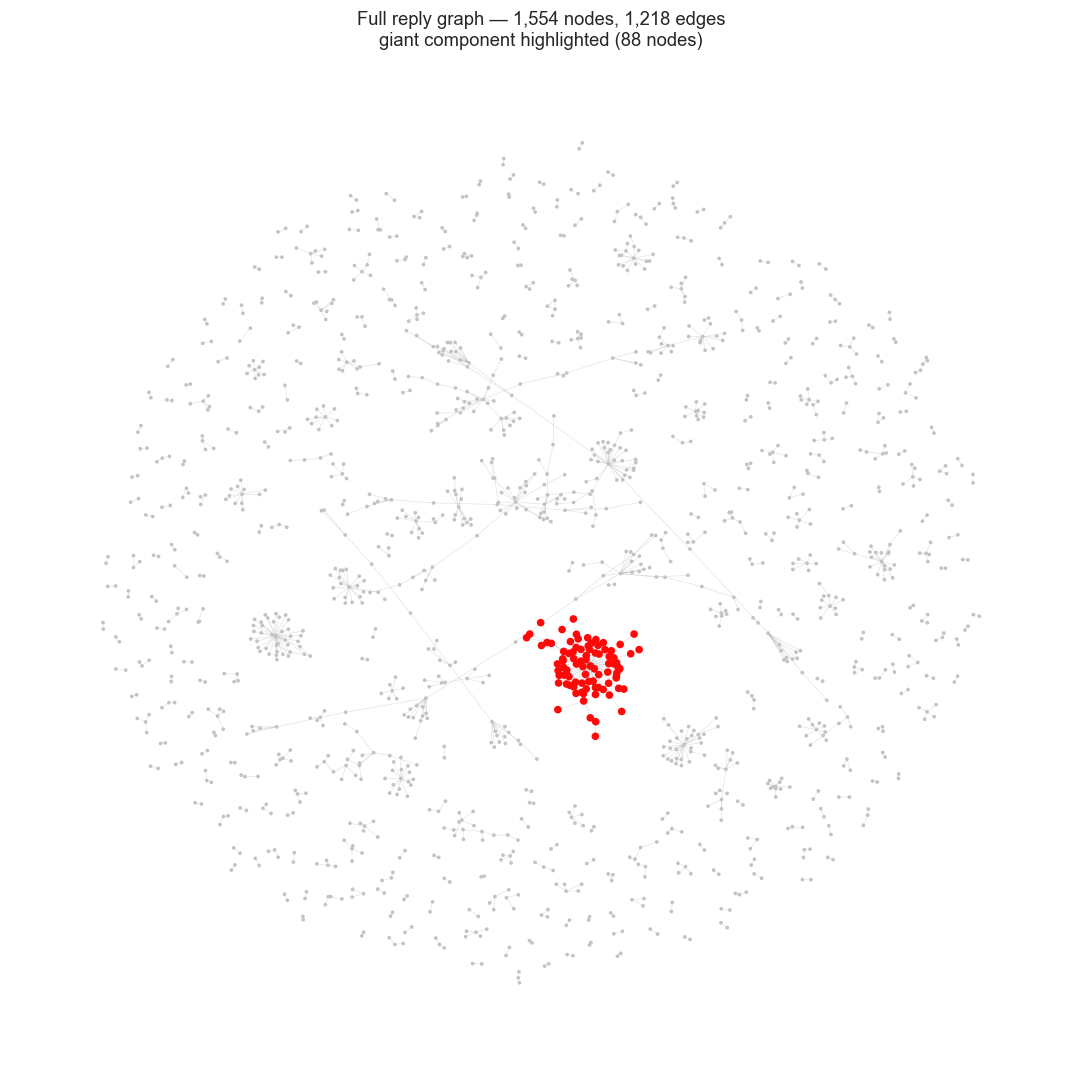

In [18]:
# Compute a layout once on the full undirected graph.
# A spring layout with low k gives a compact visualisation suitable for sparse graphs.
np.random.seed(42)
pos_full = nx.spring_layout(G_und, k=0.3, iterations=50, seed=42)

node_colors = ["#ff0808" if n in giant_nodes else "#c3c3c3" for n in G_und.nodes()]
node_sizes  = [25 if n in giant_nodes else 6 for n in G_und.nodes()]

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_edges(G_und, pos_full, alpha=0.25, width=0.4, edge_color="#888", ax=ax)
nx.draw_networkx_nodes(G_und, pos_full, node_color=node_colors, node_size=node_sizes,
                       linewidths=0, ax=ax)
ax.set_title(f"Full reply graph — {G_und.number_of_nodes():,} nodes, "
             f"{G_und.number_of_edges():,} edges\n"
             f"giant component highlighted ({len(giant_nodes)} nodes)")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_full_reply_graph.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Community detection — four algorithms

Four algorithms representing distinct methodological families are applied to the giant component.

1. **Louvain** maximises modularity through repeated local node moves. It is fast and widely used as the de facto baseline.

2. **Greedy modularity** is an agglomerative algorithm that successively merges the pair of communities yielding the highest gain in modularity. It is deterministic given the graph.

3. **Asynchronous Fluid Communities** propagates k synthetic "fluids" through the graph; communities emerge as the fluids settle into stable regions. It requires the number of communities k to be specified in advance and the graph to be connected; both conditions are satisfied here. The algorithm is run for several values of k and the partition with the highest modularity is retained.

4. **Girvan–Newman** progressively removes edges with high betweenness; communities are revealed as the graph disconnects. Its computational cost is super-quadratic, so it is applied only here, on the giant component.

For each algorithm the partition's modularity is computed against the same undirected weighted giant component.


In [19]:
def comm_to_label_dict(communities):
    """Convert an iterable of node-sets into a dict {node: community_index}."""
    out = {}
    for i, comm in enumerate(communities):
        for n in comm:
            out[n] = i
    return out


def comm_list_from_dict(label_dict):
    """Convert {node: community_index} back into a list of node-sets."""
    inv = {}
    for n, c in label_dict.items():
        inv.setdefault(c, set()).add(n)
    return list(inv.values())


partitions = {}


In [20]:
# --- Louvain ---
louvain_partition = community_louvain.best_partition(G_giant, weight="weight", random_state=42)
partitions["Louvain"] = louvain_partition
print(f"Louvain: {len(set(louvain_partition.values()))} communities")


Louvain: 10 communities


In [21]:
# --- Greedy modularity ---
greedy_comms = list(greedy_modularity_communities(G_giant, weight="weight"))
partitions["Greedy"] = comm_to_label_dict(greedy_comms)
print(f"Greedy modularity: {len(greedy_comms)} communities")


Greedy modularity: 10 communities


In [22]:
# --- Asynchronous Fluid Communities — sweep k ---
fluid_results = {}
for k in range(2, 8):
    try:
        comms = list(asyn_fluidc(G_giant, k=k, seed=42))
        m = modularity(G_giant, comms, weight="weight")
        fluid_results[k] = (m, comms)
    except Exception as e:
        fluid_results[k] = (None, None)
        print(f"  k={k}: failed ({e.__class__.__name__})")

# Pick the k with highest modularity
valid_k = {k: v for k, v in fluid_results.items() if v[0] is not None}
best_k = max(valid_k, key=lambda k: valid_k[k][0])
best_mod_fluid, best_comms_fluid = valid_k[best_k]
partitions["FluidC"] = comm_to_label_dict(best_comms_fluid)

print(f"\nFluidC modularity by k:")
for k, (m, _) in fluid_results.items():
    marker = " ← selected" if k == best_k else ""
    print(f"  k={k}: modularity = {m:.4f}{marker}" if m is not None else f"  k={k}: failed")



FluidC modularity by k:
  k=2: modularity = 0.2220
  k=3: modularity = 0.2250
  k=4: modularity = 0.2391
  k=5: modularity = 0.2689 ← selected
  k=6: modularity = 0.2560
  k=7: modularity = 0.2143


In [23]:
# --- Girvan-Newman — pick partition with highest modularity along the dendrogram ---
gn_generator = girvan_newman(G_giant)

best_gn_mod = -1
best_gn_comms = None
# Iterate through dendrogram cuts; cap at 20 levels for runtime safety
for i, level in enumerate(gn_generator):
    comms = [set(c) for c in level]
    m = modularity(G_giant, comms, weight="weight")
    if m > best_gn_mod:
        best_gn_mod = m
        best_gn_comms = comms
    if i >= 20:
        break

partitions["Girvan-Newman"] = comm_to_label_dict(best_gn_comms)
print(f"Girvan-Newman: {len(best_gn_comms)} communities at best cut (modularity = {best_gn_mod:.4f})")


Girvan-Newman: 11 communities at best cut (modularity = 0.4112)


## 12. Algorithm comparison

The four partitions are summarised side by side: number of communities, sizes, modularity.

Pairwise agreement is then measured with Adjusted Rand Index (ARI) and Normalised Mutual Information (NMI), which range from 0 (independent partitions) to 1 (identical partitions).


In [24]:
rows = []
for name, part_dict in partitions.items():
    comms = comm_list_from_dict(part_dict)
    sizes = [len(c) for c in comms]
    rows.append({
        "algorithm":        name,
        "n_communities":    len(comms),
        "modularity":       round(modularity(G_giant, comms, weight="weight"), 4),
        "largest_comm":     max(sizes),
        "smallest_comm":    min(sizes),
        "median_comm_size": int(np.median(sizes)),
    })

community_comparison = pd.DataFrame(rows).set_index("algorithm")
community_comparison


,n_communities,modularity,largest_comm,smallest_comm,median_comm_size
algorithm,,,,,
Louvain,10,0.4199,50,2,3
Greedy,10,0.4199,50,2,3
FluidC,5,0.2689,34,6,9
Girvan-Newman,11,0.4112,50,2,2


In [25]:
# Pairwise ARI and NMI — align labels by node order
nodes_giant = sorted(G_giant.nodes())
label_vectors = {
    name: [partitions[name].get(n, -1) for n in nodes_giant]
    for name in partitions
}

algos = list(partitions.keys())
ari_matrix = pd.DataFrame(index=algos, columns=algos, dtype=float)
nmi_matrix = pd.DataFrame(index=algos, columns=algos, dtype=float)

for a in algos:
    for b in algos:
        ari_matrix.loc[a, b] = adjusted_rand_score(label_vectors[a], label_vectors[b])
        nmi_matrix.loc[a, b] = normalized_mutual_info_score(label_vectors[a], label_vectors[b])

print("Adjusted Rand Index (ARI):")
print(ari_matrix.round(3))
print("\nNormalised Mutual Information (NMI):")
print(nmi_matrix.round(3))


Adjusted Rand Index (ARI):
               Louvain  Greedy  FluidC  Girvan-Newman
Louvain          1.000   0.963   0.375          0.968
Greedy           0.963   1.000   0.385          0.968
FluidC           0.375   0.385   1.000          0.391
Girvan-Newman    0.968   0.968   0.391          1.000

Normalised Mutual Information (NMI):
               Louvain  Greedy  FluidC  Girvan-Newman
Louvain          1.000   0.943   0.602          0.938
Greedy           0.943   1.000   0.613          0.938
FluidC           0.602   0.613   1.000          0.628
Girvan-Newman    0.938   0.938   0.628          1.000


### Figure: algorithm comparison

Modularity scores side by side, paired with the heatmap of pairwise agreement between the four partitions.
The two views complement each other: the bar chart shows *how modular* each partition is, the heatmap shows *how similar* the partitions are to each other.


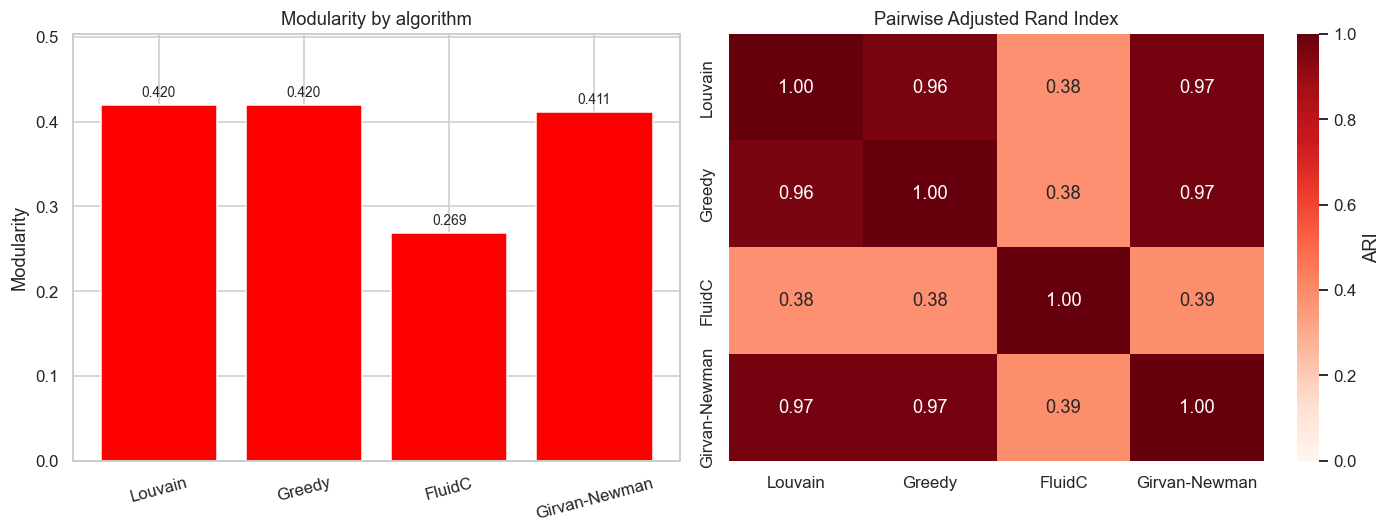

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.1]})

# Left: modularity by algorithm
mod_series = community_comparison["modularity"]
axes[0].bar(mod_series.index, mod_series.values, color="#ff0000", edgecolor="white")
axes[0].set_ylabel("Modularity")
axes[0].set_title("Modularity by algorithm")
axes[0].set_ylim(0, max(mod_series.values) * 1.2)
for i, v in enumerate(mod_series.values):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
axes[0].tick_params(axis="x", rotation=15)

# Right: ARI heatmap
sns.heatmap(
    ari_matrix.astype(float).round(2),
    annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1,
    cbar_kws={"label": "ARI"}, ax=axes[1],
)
axes[1].set_title("Pairwise Adjusted Rand Index")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_algorithm_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Community characterisation — Louvain partition

The Louvain partition is taken as the reference for downstream content analysis because it provides a well-established, scalable and interpretable modularity-based partition. The other algorithms are kept as sensitivity checks: Greedy Modularity and Girvan–Newman produce highly consistent partitions, while FluidC offers a more divergent diffusion-based perspective because it requires the number of communities to be specified in advance.

For each Louvain community of substantial size, the most central nodes and a small qualitative profile are reported.


In [27]:
louvain_df = pd.DataFrame({
    "author": list(louvain_partition.keys()),
    "community": list(louvain_partition.values()),
})
louvain_df["in_degree"] = louvain_df["author"].map(centrality_giant["in_degree"])
louvain_df["is_likely_promo"] = louvain_df["author"].isin(promo_authors)

comm_sizes = louvain_df["community"].value_counts().sort_values(ascending=False)
print(f"Louvain communities by size (top 10):")
print(comm_sizes.head(10))


Louvain communities by size (top 10):
community
0    50
6    12
2     6
5     6
9     4
3     2
4     2
8     2
1     2
7     2
Name: count, dtype: int64


In [28]:
for c in comm_sizes.head(5).index:
    members = louvain_df[louvain_df["community"] == c].sort_values("in_degree", ascending=False)
    print(f"\n── Community {c}: {len(members)} members ──")
    print("Top 5 by in-degree within the community:")
    print(members.head(5)[["author", "in_degree", "is_likely_promo"]].to_string(index=False))



── Community 0: 50 members ──
Top 5 by in-degree within the community:
                        author  in_degree  is_likely_promo
      squeakyllama.bsky.social         69            False
        aoife-rose.bsky.social          1            False
           lindavt.bsky.social          0            False
          tofuhama.bsky.social          0            False
boondockingintheus.bsky.social          0            False

── Community 6: 12 members ──
Top 5 by in-degree within the community:
                    author  in_degree  is_likely_promo
        prdnme.bsky.social          7            False
       polly-o.bsky.social          4            False
silentbrouhaha.bsky.social          4            False
  tydyethefly.blacksky.app          0            False
       tinamur.bsky.social          0            False

── Community 2: 6 members ──
Top 5 by in-degree within the community:
                    author  in_degree  is_likely_promo
     philcox99.bsky.social          2         

### Figure: giant component coloured by community

The giant component visualised with a spring layout, with nodes coloured by their Louvain community assignment and node sizes scaled by in-degree. The view makes the modular structure explicit: a dominant cluster around the most-replied seed post, plus several smaller satellite communities corresponding to secondary reply trees.


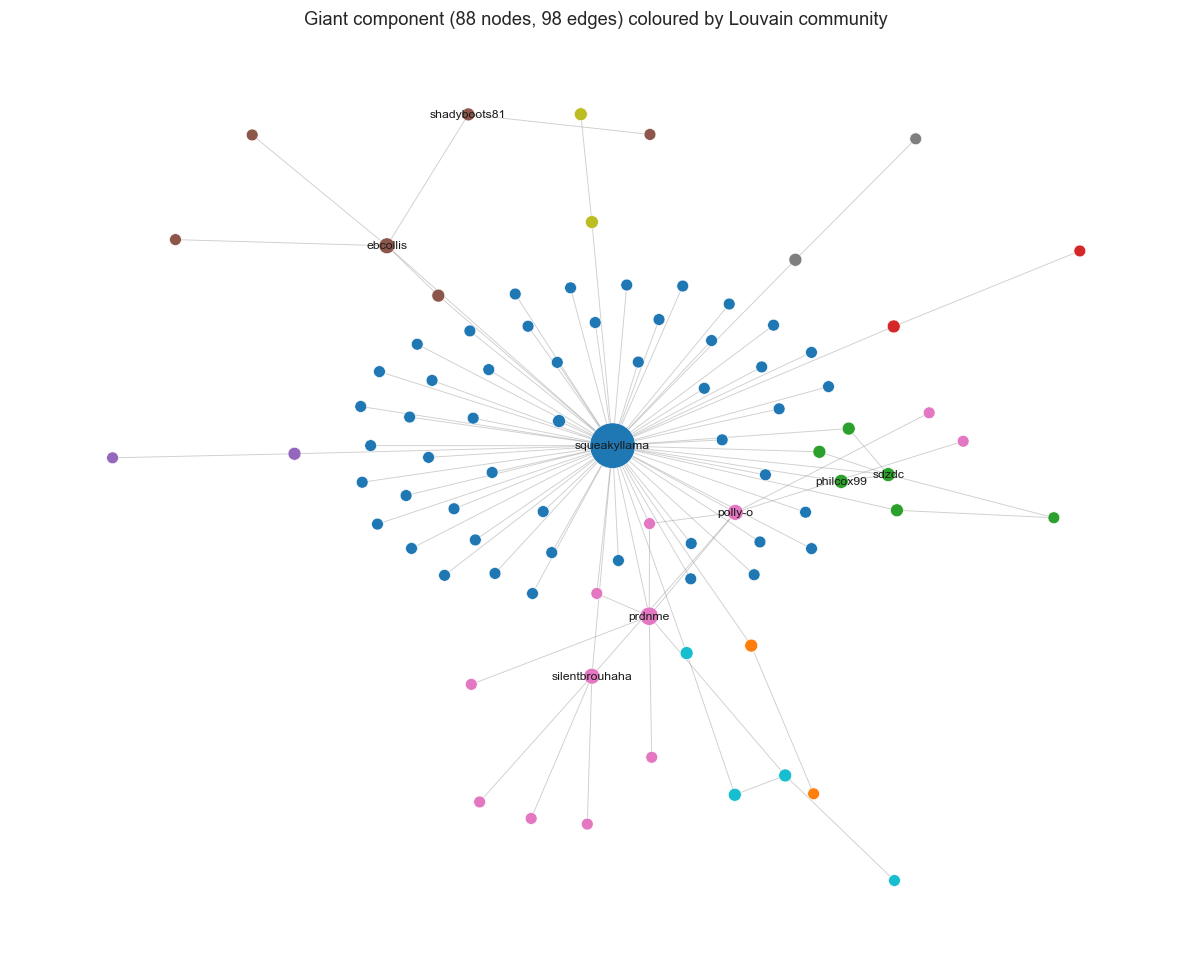

In [29]:
np.random.seed(42)
pos_giant = nx.spring_layout(G_giant, k=0.5, iterations=100, seed=42)

community_ids = sorted(set(louvain_partition.values()))
palette = sns.color_palette("tab10", n_colors=len(community_ids))
color_map = {cid: palette[i] for i, cid in enumerate(community_ids)}

node_color = [color_map[louvain_partition[n]] for n in G_giant.nodes()]
node_size  = [60 + centrality_giant.loc[n, "in_degree"] * 12 for n in G_giant.nodes()]

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(G_giant, pos_giant, alpha=0.4, width=0.6, edge_color="#888", ax=ax)
nx.draw_networkx_nodes(G_giant, pos_giant, node_color=node_color, node_size=node_size,
                       linewidths=0.4, edgecolors="white", ax=ax)

# Label only the most central nodes to keep the figure readable.
top_to_label = (
    centrality_giant.sort_values("in_degree", ascending=False)
                    .head(8).index.tolist()
)
labels = {n: n.replace(".bsky.social", "") for n in top_to_label}
nx.draw_networkx_labels(G_giant, pos_giant, labels=labels, font_size=8, ax=ax)

ax.set_title(f"Giant component ({G_giant.number_of_nodes()} nodes, {G_giant.number_of_edges()} edges) "
             f"coloured by Louvain community")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_giant_component_louvain.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Save outputs

Every derived dataset is saved under `data/processed/`. The directed and undirected graphs are exported in GEXF format for exploration in Gephi if needed; the edge list, centrality tables and community assignments are saved as CSV for direct loading in the content-analysis notebook.


In [30]:
# Edge list
edges_weighted.to_csv(PROC_DIR / "reply_edges.csv", index=False)

# Node attributes
node_attrs = pd.DataFrame({
    "author":           list(G_und.nodes()),
    "is_likely_promo":  [G_und.nodes[n].get("is_likely_promo", False) for n in G_und.nodes()],
    "in_giant_component": [n in giant_nodes for n in G_und.nodes()],
})
node_attrs.to_csv(PROC_DIR / "node_attributes.csv", index=False)

# Centrality tables
centrality_full.to_csv(PROC_DIR / "centrality_full.csv")
centrality_giant.to_csv(PROC_DIR / "centrality_giant.csv")

# Community assignments — one column per algorithm, nodes restricted to the giant
community_assignments = pd.DataFrame({
    "author": nodes_giant,
})
for name in partitions:
    community_assignments[name] = community_assignments["author"].map(partitions[name])
community_assignments.to_csv(PROC_DIR / "community_assignments.csv", index=False)

# Algorithm comparison
community_comparison.to_csv(PROC_DIR / "community_comparison.csv")
ari_matrix.to_csv(PROC_DIR / "community_ari.csv")
nmi_matrix.to_csv(PROC_DIR / "community_nmi.csv")

# Graphs in GEXF (the boolean node attribute is serialised as int for GEXF compatibility)
G_dir_export = G_dir.copy()
G_und_export = G_und.copy()
for G_ in (G_dir_export, G_und_export):
    for n in G_.nodes():
        G_.nodes[n]["is_likely_promo"] = int(G_.nodes[n].get("is_likely_promo", False))
nx.write_gexf(G_dir_export, PROC_DIR / "reply_graph_directed.gexf")
nx.write_gexf(G_und_export, PROC_DIR / "reply_graph_undirected.gexf")

print("Saved to data/processed/:")
for name in (
    "reply_edges.csv",
    "node_attributes.csv",
    "centrality_full.csv",
    "centrality_giant.csv",
    "community_assignments.csv",
    "community_comparison.csv",
    "community_ari.csv",
    "community_nmi.csv",
    "reply_graph_directed.gexf",
    "reply_graph_undirected.gexf",
):
    print(" -", PROC_DIR / name)


Saved to data/processed/:
 - ../data/processed/reply_edges.csv
 - ../data/processed/node_attributes.csv
 - ../data/processed/centrality_full.csv
 - ../data/processed/centrality_giant.csv
 - ../data/processed/community_assignments.csv
 - ../data/processed/community_comparison.csv
 - ../data/processed/community_ari.csv
 - ../data/processed/community_nmi.csv
 - ../data/processed/reply_graph_directed.gexf
 - ../data/processed/reply_graph_undirected.gexf


## 15. Summary

 The reply network on the full dataset consists of about 1 200 weighted edges connecting roughly 1 550 authors, distributed across hundreds of small connected components. The giant component, while small in absolute terms (less than six per cent of all nodes), is the only sub-structure dense enough for meaningful community detection: it is here that the four algorithms have been compared.
Their partitions agree on the broad shape of the conversation, which is dominated by a handful of high-engagement seed posts whose reply trees define the communities.

The next notebook uses the per-author community assignments produced here together with the post text to characterise each community thematically: which audience each one corresponds to, what sentiment and emotion profile it carries, and which named entities it references most frequently.
